# Feature Engineering

In [28]:
# Create date-time / or Time-Based Features
df_epde_combine["hour"] = df_epde_combine.index.hour
df_epde_combine["dayofweek"] = df_epde_combine.index.dayofweek
df_epde_combine['is_weekend'] = df_epde_combine["dayofweek"].isin([5,6]).astype(int)
df_epde_combine["quarter"] = df_epde_combine.index.quarter
df_epde_combine["month"] = df_epde_combine.index.month
df_epde_combine["year"] = df_epde_combine.index.year
df_epde_combine["dayofyear"] = df_epde_combine.index.dayofyear
df_epde_combine.head()

,Germany/Luxembourg_EUR/MWh_Calculated_resolution,Grid_load_MWh_Calculated_resolutions_actual,Grid_load_MWh_Calculated_resolutions_predicted,Predicted_Residual_load_MWh_Calculated_resolutions,Total_MWh_Calculated_resolutions,Photovoltaics_and_wind_MWh_Calculated_resolutions,Offshore_wind_MWh_Calculated_resolutions,Wind_Onshore_MWh_Calculated_resolutions,Photovoltaics_MWh_Calculated_resolutions,Other_MWh_Calculated_resolutions,t2m_degree_celsius,wind_speed_m/s,hour,dayofweek,is_weekend,quarter,month,year,dayofyear
timestamp,,,,,,,,,,,,,,,,,,,
2015-01-05 00:00:00,22.34,46668.00,43176.00,32614.50,50766.21,10561.5,551.75,10009.75,0.0,40204.71,1.11,4.517831,0,0,0,1,1,2015,5
2015-01-05 01:00:00,17.93,44627.00,41597.75,30762.25,49056.05,10835.5,547.75,10287.75,0.0,38220.55,1.08,4.475748,1,0,0,1,1,2015,5
2015-01-05 02:00:00,15.17,43635.50,40421.75,29460.75,48213.56,10961.0,542.50,10418.50,0.0,37252.56,1.03,4.479349,2,0,0,1,1,2015,5
2015-01-05 03:00:00,16.38,43683.25,40404.25,29268.75,48132.63,11135.5,533.75,10601.75,0.0,36997.13,0.98,4.538027,3,0,0,1,1,2015,5
2015-01-05 04:00:00,17.38,44969.25,41348.25,30016.75,49368.99,11331.5,521.75,10809.75,0.0,38037.49,0.88,4.605614,4,0,0,1,1,2015,5


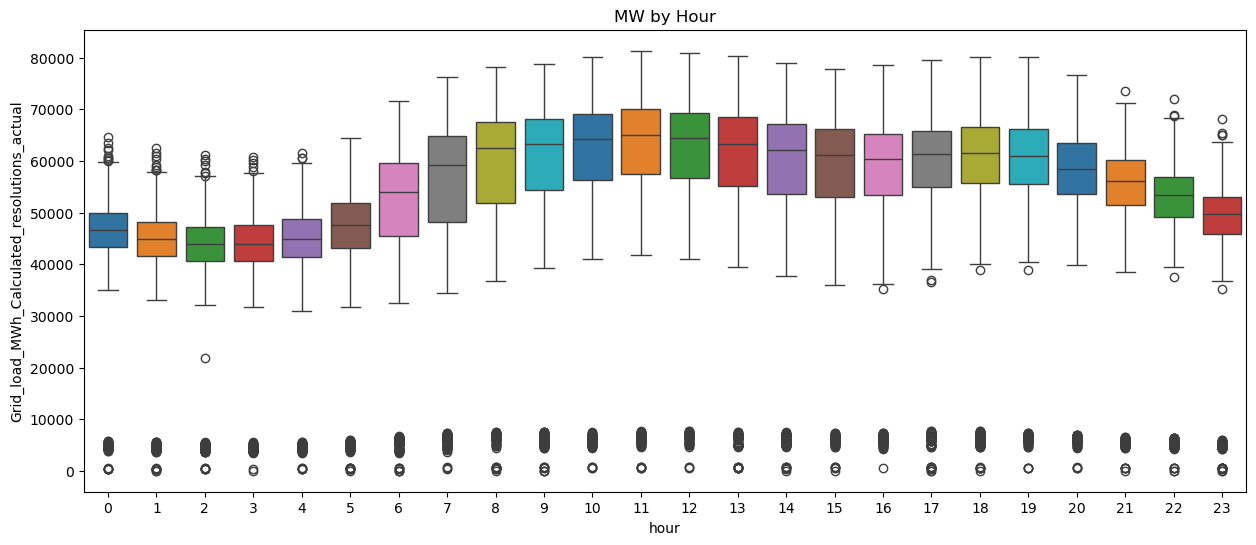

In [29]:
# Boxplot to visualize distribution of Grid Load [MWh] Calculated resolutions actual across different Hours
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df_epde_combine, x="hour", y="Grid_load_MWh_Calculated_resolutions_actual", hue="hour", palette="tab10", legend=False)
ax.set_title("MW by Hour");

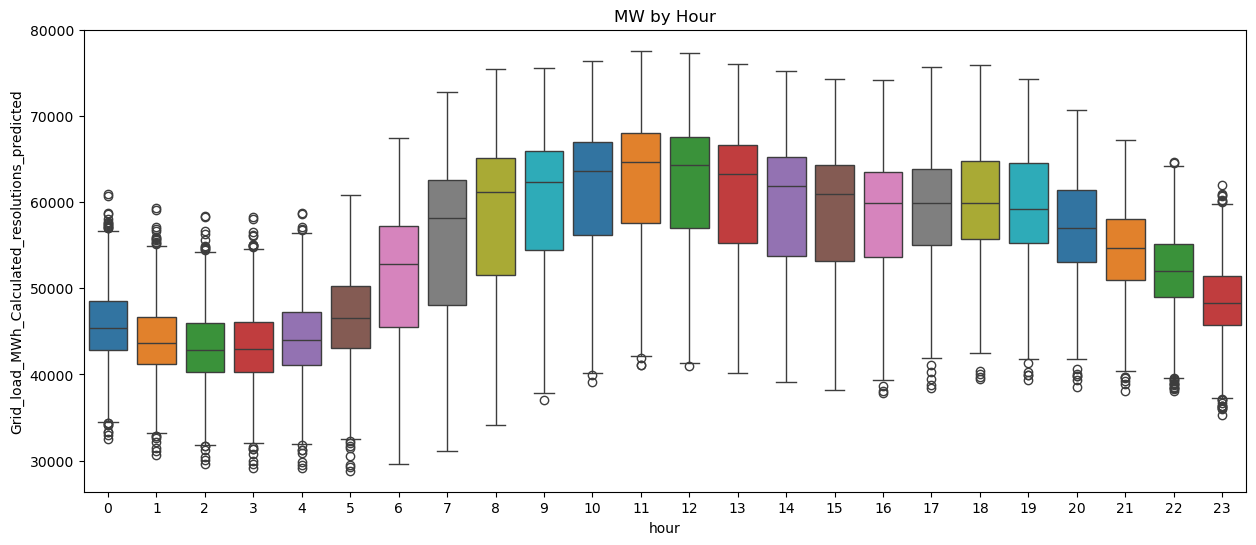

In [30]:
# Boxplot to visualize distribution of Grid Load [MWh] Calculated resolutions predicted across different Hours
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df_epde_combine, x="hour", y="Grid_load_MWh_Calculated_resolutions_predicted", hue="hour", palette="tab10", legend=False)
ax.set_title("MW by Hour");

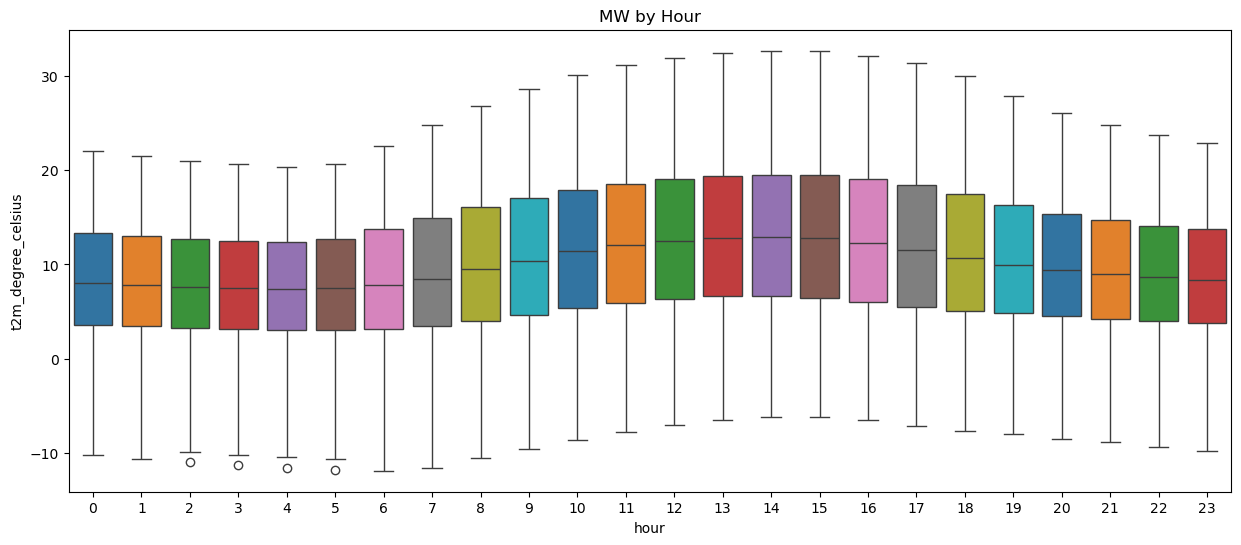

In [31]:
# Boxplot to visualize distribution of Weather Temperatureinin celsius across different Hours
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df_epde_combine, x="hour", y="t2m_degree_celsius", hue="hour", palette="tab10", legend=False)
ax.set_title("MW by Hour");

# Lag Features for Grid load [MWh] Calculated resolutions_actual, Germany/Luxembourg [EUR/MWh] Calculated resolution, t2m, wind_speed

In [32]:
def create_features(df, actual_features=["Grid_load_MWh_Calculated_resolutions_actual",
                                                     "t2m_degree_celsius",
                                                     "wind_speed_m/s"],
                    target = "Germany/Luxembourg_EUR/MWh_Calculated_resolution", 
                    lags= [1, 2, 6, 24, 168],
                    rollings_window_features = [24, 168]):
    
    
    df = df.copy()
    
    for lag in lags:
        for actual_feat in actual_features:
            df[f"{actual_feat}_lag_{lag}"] = df[actual_feat].shift(lag)
        df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for rol in rollings_window_features:
            df[f"{target}_roll_mean_{rol}"] = df[target].shift(1).rolling(rol).mean()
            df[f"{target}_roll_std_{rol}"] = df[target].shift(1).rolling(rol).std()
            df[f"{target}_roll_mean_{rol}"] = df[target].shift(1).rolling(rol).mean()

            
    return df

    
df_epde_combine = create_features(df_epde_combine)
df_epde_combine.head()

,Germany/Luxembourg_EUR/MWh_Calculated_resolution,Grid_load_MWh_Calculated_resolutions_actual,Grid_load_MWh_Calculated_resolutions_predicted,Predicted_Residual_load_MWh_Calculated_resolutions,Total_MWh_Calculated_resolutions,Photovoltaics_and_wind_MWh_Calculated_resolutions,Offshore_wind_MWh_Calculated_resolutions,Wind_Onshore_MWh_Calculated_resolutions,Photovoltaics_MWh_Calculated_resolutions,Other_MWh_Calculated_resolutions,...,wind_speed_m/s_lag_6,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_6,Grid_load_MWh_Calculated_resolutions_actual_lag_24,t2m_degree_celsius_lag_24,wind_speed_m/s_lag_24,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_24,Grid_load_MWh_Calculated_resolutions_actual_lag_168,t2m_degree_celsius_lag_168,wind_speed_m/s_lag_168,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_168
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-05 00:00:00,22.34,46668.00,43176.00,32614.50,50766.21,10561.5,551.75,10009.75,0.0,40204.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05 01:00:00,17.93,44627.00,41597.75,30762.25,49056.05,10835.5,547.75,10287.75,0.0,38220.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05 02:00:00,15.17,43635.50,40421.75,29460.75,48213.56,10961.0,542.50,10418.50,0.0,37252.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05 03:00:00,16.38,43683.25,40404.25,29268.75,48132.63,11135.5,533.75,10601.75,0.0,36997.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05 04:00:00,17.38,44969.25,41348.25,30016.75,49368.99,11331.5,521.75,10809.75,0.0,38037.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


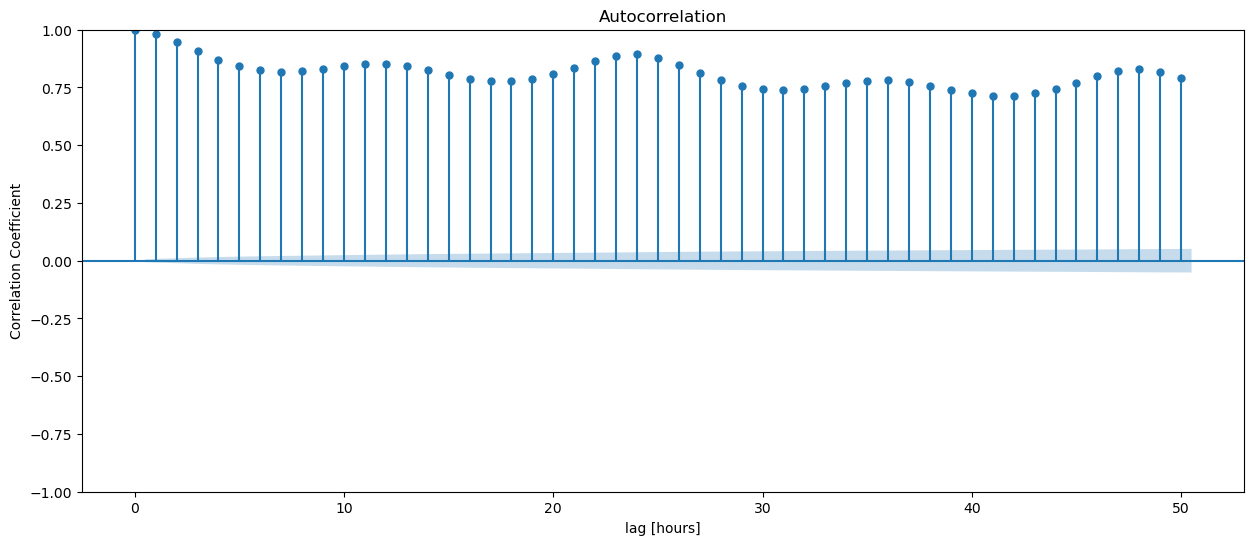

In [34]:
# Create an ACF plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df_epde_combine["Germany/Luxembourg_EUR/MWh_Calculated_resolution"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

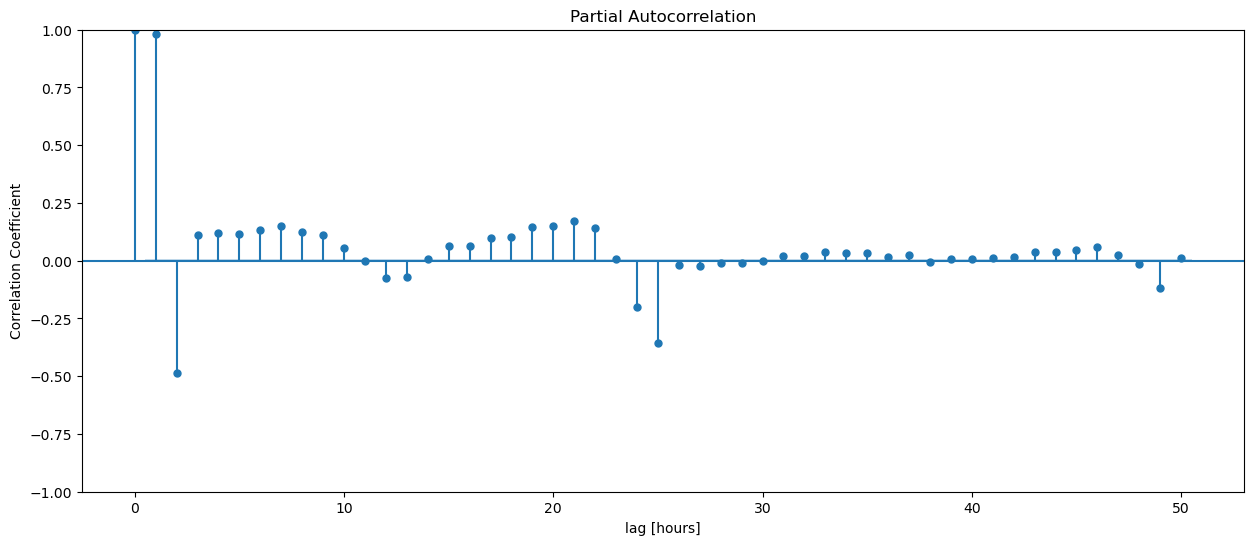

In [35]:
# Create an PACF plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_epde_combine["Germany/Luxembourg_EUR/MWh_Calculated_resolution"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

In [36]:
# Drop "Grid_load_MWh_Calculated_resolutions_actual", "t2m_degree_celsius", "wind_speed_m/s" columns to avoid data leakage

df_elec_price = df_epde_combine.drop(columns=["Grid_load_MWh_Calculated_resolutions_actual", 
                                                  "t2m_degree_celsius", "wind_speed_m/s"])
df_elec_price = df_elec_price.dropna()  
df_elec_price = df_elec_price.sort_index()
df_elec_price

,Germany/Luxembourg_EUR/MWh_Calculated_resolution,Grid_load_MWh_Calculated_resolutions_predicted,Predicted_Residual_load_MWh_Calculated_resolutions,Total_MWh_Calculated_resolutions,Photovoltaics_and_wind_MWh_Calculated_resolutions,Offshore_wind_MWh_Calculated_resolutions,Wind_Onshore_MWh_Calculated_resolutions,Photovoltaics_MWh_Calculated_resolutions,Other_MWh_Calculated_resolutions,hour,...,wind_speed_m/s_lag_6,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_6,Grid_load_MWh_Calculated_resolutions_actual_lag_24,t2m_degree_celsius_lag_24,wind_speed_m/s_lag_24,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_24,Grid_load_MWh_Calculated_resolutions_actual_lag_168,t2m_degree_celsius_lag_168,wind_speed_m/s_lag_168,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_168
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-12 00:00:00,9.30,45184.75,16821.50,55535.94,28363.25,637.75,27725.50,0.0,27172.69,0,...,8.195358,11.44,47395.00,5.50,7.755997,0.05,46668.00,1.11,4.517831,22.34
2015-01-12 01:00:00,2.87,43427.75,16399.25,52368.46,27028.50,638.25,26390.25,0.0,25339.96,1,...,8.107873,14.88,44603.25,5.07,7.607651,-2.06,44627.00,1.08,4.475748,17.93
2015-01-12 02:00:00,0.09,42625.50,16057.50,52079.33,26568.00,638.50,25929.50,0.0,25511.33,2,...,7.962293,9.63,43388.75,4.59,7.412736,-4.11,43635.50,1.03,4.479349,15.17
2015-01-12 03:00:00,0.26,42934.25,16710.75,52309.15,26223.50,638.25,25585.25,0.0,26085.65,3,...,7.749416,9.29,43037.00,4.14,7.302162,-5.06,43683.25,0.98,4.538027,16.38
2015-01-12 04:00:00,2.83,44453.25,18338.25,53740.00,26115.00,640.00,25475.00,0.0,27625.00,4,...,7.539843,10.18,43354.25,3.73,7.271597,-4.12,44969.25,0.88,4.605614,17.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,95.99,60858.50,30182.90,58770.98,30675.61,5430.05,25245.56,0.0,28095.37,19,...,5.120333,85.17,61140.28,-1.94,3.857948,105.61,53304.01,-1.71,6.377553,71.77
2025-12-31 20:00:00,86.80,58151.00,26520.07,58432.08,31630.94,5494.99,26135.95,0.0,26801.15,20,...,5.004774,85.18,57869.49,-2.31,3.717385,101.04,51025.41,-1.94,6.310756,68.16
2025-12-31 21:00:00,79.80,55475.72,22865.34,57524.63,32610.38,5359.10,27251.28,0.0,24914.24,21,...,4.870044,90.83,55842.04,-2.68,3.629845,93.32,49741.21,-2.16,6.198000,67.99


In [37]:
# Check the missing values and columns
df_elec_price.isnull().sum()

Germany/Luxembourg_EUR/MWh_Calculated_resolution                  0
Grid_load_MWh_Calculated_resolutions_predicted                    0
Predicted_Residual_load_MWh_Calculated_resolutions                0
Total_MWh_Calculated_resolutions                                  0
Photovoltaics_and_wind_MWh_Calculated_resolutions                 0
Offshore_wind_MWh_Calculated_resolutions                          0
Wind_Onshore_MWh_Calculated_resolutions                           0
Photovoltaics_MWh_Calculated_resolutions                          0
Other_MWh_Calculated_resolutions                                  0
hour                                                              0
dayofweek                                                         0
is_weekend                                                        0
quarter                                                           0
month                                                             0
year                                            

In [38]:
# Check the Shape again
df_elec_price.shape

(96168, 40)

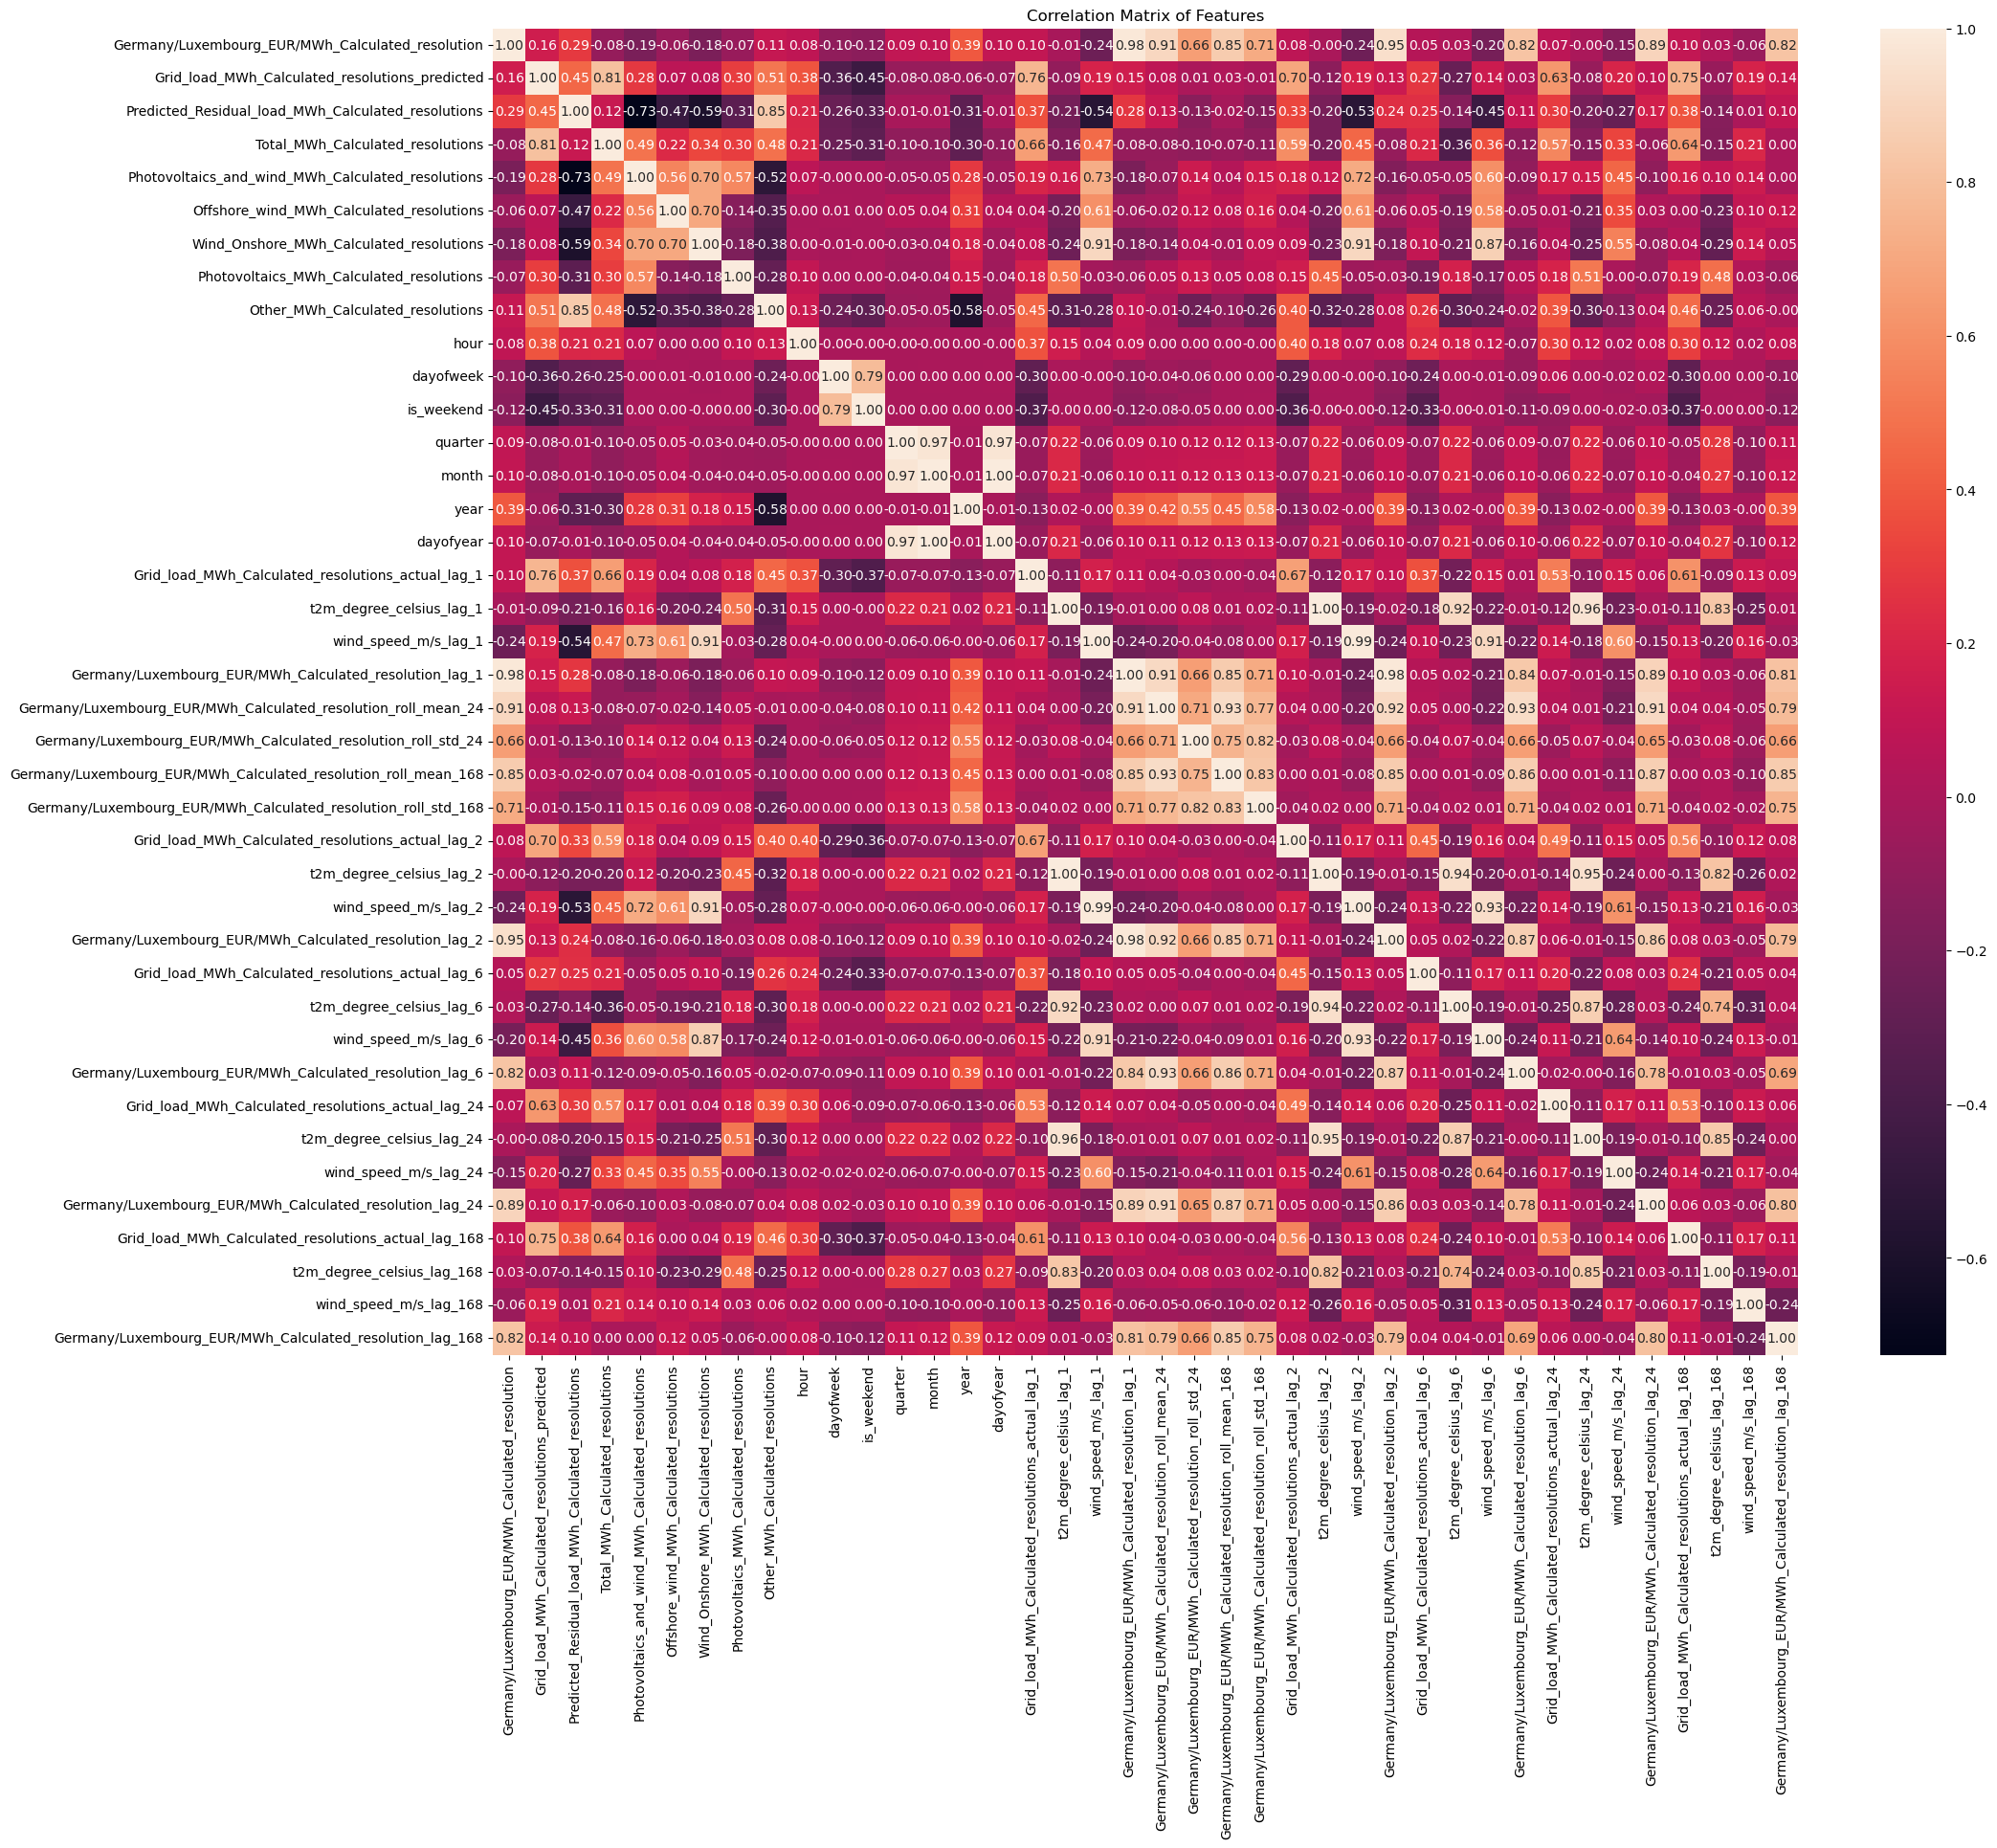

In [39]:
# Correlation Matrix
plt.figure(figsize=(22, 18))
sns.heatmap(df_elec_price.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

In [40]:
# Check full correlation matrix numbers
df_elec_price.corr()

,Germany/Luxembourg_EUR/MWh_Calculated_resolution,Grid_load_MWh_Calculated_resolutions_predicted,Predicted_Residual_load_MWh_Calculated_resolutions,Total_MWh_Calculated_resolutions,Photovoltaics_and_wind_MWh_Calculated_resolutions,Offshore_wind_MWh_Calculated_resolutions,Wind_Onshore_MWh_Calculated_resolutions,Photovoltaics_MWh_Calculated_resolutions,Other_MWh_Calculated_resolutions,hour,...,wind_speed_m/s_lag_6,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_6,Grid_load_MWh_Calculated_resolutions_actual_lag_24,t2m_degree_celsius_lag_24,wind_speed_m/s_lag_24,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_24,Grid_load_MWh_Calculated_resolutions_actual_lag_168,t2m_degree_celsius_lag_168,wind_speed_m/s_lag_168,Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_168
Germany/Luxembourg_EUR/MWh_Calculated_resolution,1.000000,0.156290,0.290802,-0.083879,-0.192461,-0.059593,-0.182515,-0.071087,0.111351,8.370264e-02,...,-0.204381,0.824268,0.070979,-0.003048,-0.152392,0.894591,0.102706,0.028603,-0.059110,0.823173
Grid_load_MWh_Calculated_resolutions_predicted,0.156290,1.000000,0.453372,0.807597,0.283449,0.071755,0.078967,0.299759,0.506579,3.846194e-01,...,0.140254,0.026299,0.631536,-0.075108,0.195357,0.101362,0.746744,-0.065402,0.190223,0.140671
Predicted_Residual_load_MWh_Calculated_resolutions,0.290802,0.453372,1.000000,0.120811,-0.726106,-0.467525,-0.594688,-0.313574,0.848743,2.069926e-01,...,-0.454453,0.105022,0.298197,-0.197297,-0.274075,0.165589,0.382250,-0.142432,0.005478,0.097108
Total_MWh_Calculated_resolutions,-0.083879,0.807597,0.120811,1.000000,0.493211,0.219621,0.336146,0.301469,0.484210,2.119115e-01,...,0.362990,-0.117842,0.568411,-0.145498,0.326113,-0.063749,0.640011,-0.150018,0.210589,0.003939
Photovoltaics_and_wind_MWh_Calculated_resolutions,-0.192461,0.283449,-0.726106,0.493211,1.000000,0.558134,0.700610,0.568966,-0.522311,7.408570e-02,...,0.597103,-0.092851,0.166612,0.154561,0.445598,-0.100096,0.164899,0.102946,0.140811,0.003892
Offshore_wind_MWh_Calculated_resolutions,-0.059593,0.071755,-0.467525,0.219621,0.558134,1.000000,0.701467,-0.136479,-0.346079,1.823992e-03,...,0.577023,-0.047964,0.012794,-0.206036,0.347831,0.027830,0.002329,-0.234514,0.099145,0.118741
Wind_Onshore_MWh_Calculated_resolutions,-0.182515,0.078967,-0.594688,0.336146,0.700610,0.701467,1.000000,-0.179092,-0.375153,4.125045e-03,...,0.872123,-0.163422,0.043797,-0.253134,0.545199,-0.078401,0.036838,-0.285478,0.140584,0.045078
Photovoltaics_MWh_Calculated_resolutions,-0.071087,0.299759,-0.313574,0.301469,0.568966,-0.136479,-0.179092,1.000000,-0.276739,9.848665e-02,...,-0.168457,0.045772,0.184838,0.512706,-0.002103,-0.065660,0.191621,0.479413,0.033561,-0.064346
Other_MWh_Calculated_resolutions,0.111351,0.506579,0.848743,0.484210,-0.522311,-0.346079,-0.375153,-0.276739,1.000000,1.332175e-01,...,-0.244732,-0.022129,0.389624,-0.298086,-0.128498,0.038184,0.461535,-0.250602,0.064810,-0.000053
hour,0.083703,0.384619,0.206993,0.211911,0.074086,0.001824,0.004125,0.098487,0.133217,1.000000e+00,...,0.118877,-0.067851,0.301041,0.123100,0.021174,0.083703,0.301036,0.123219,0.021440,0.083614


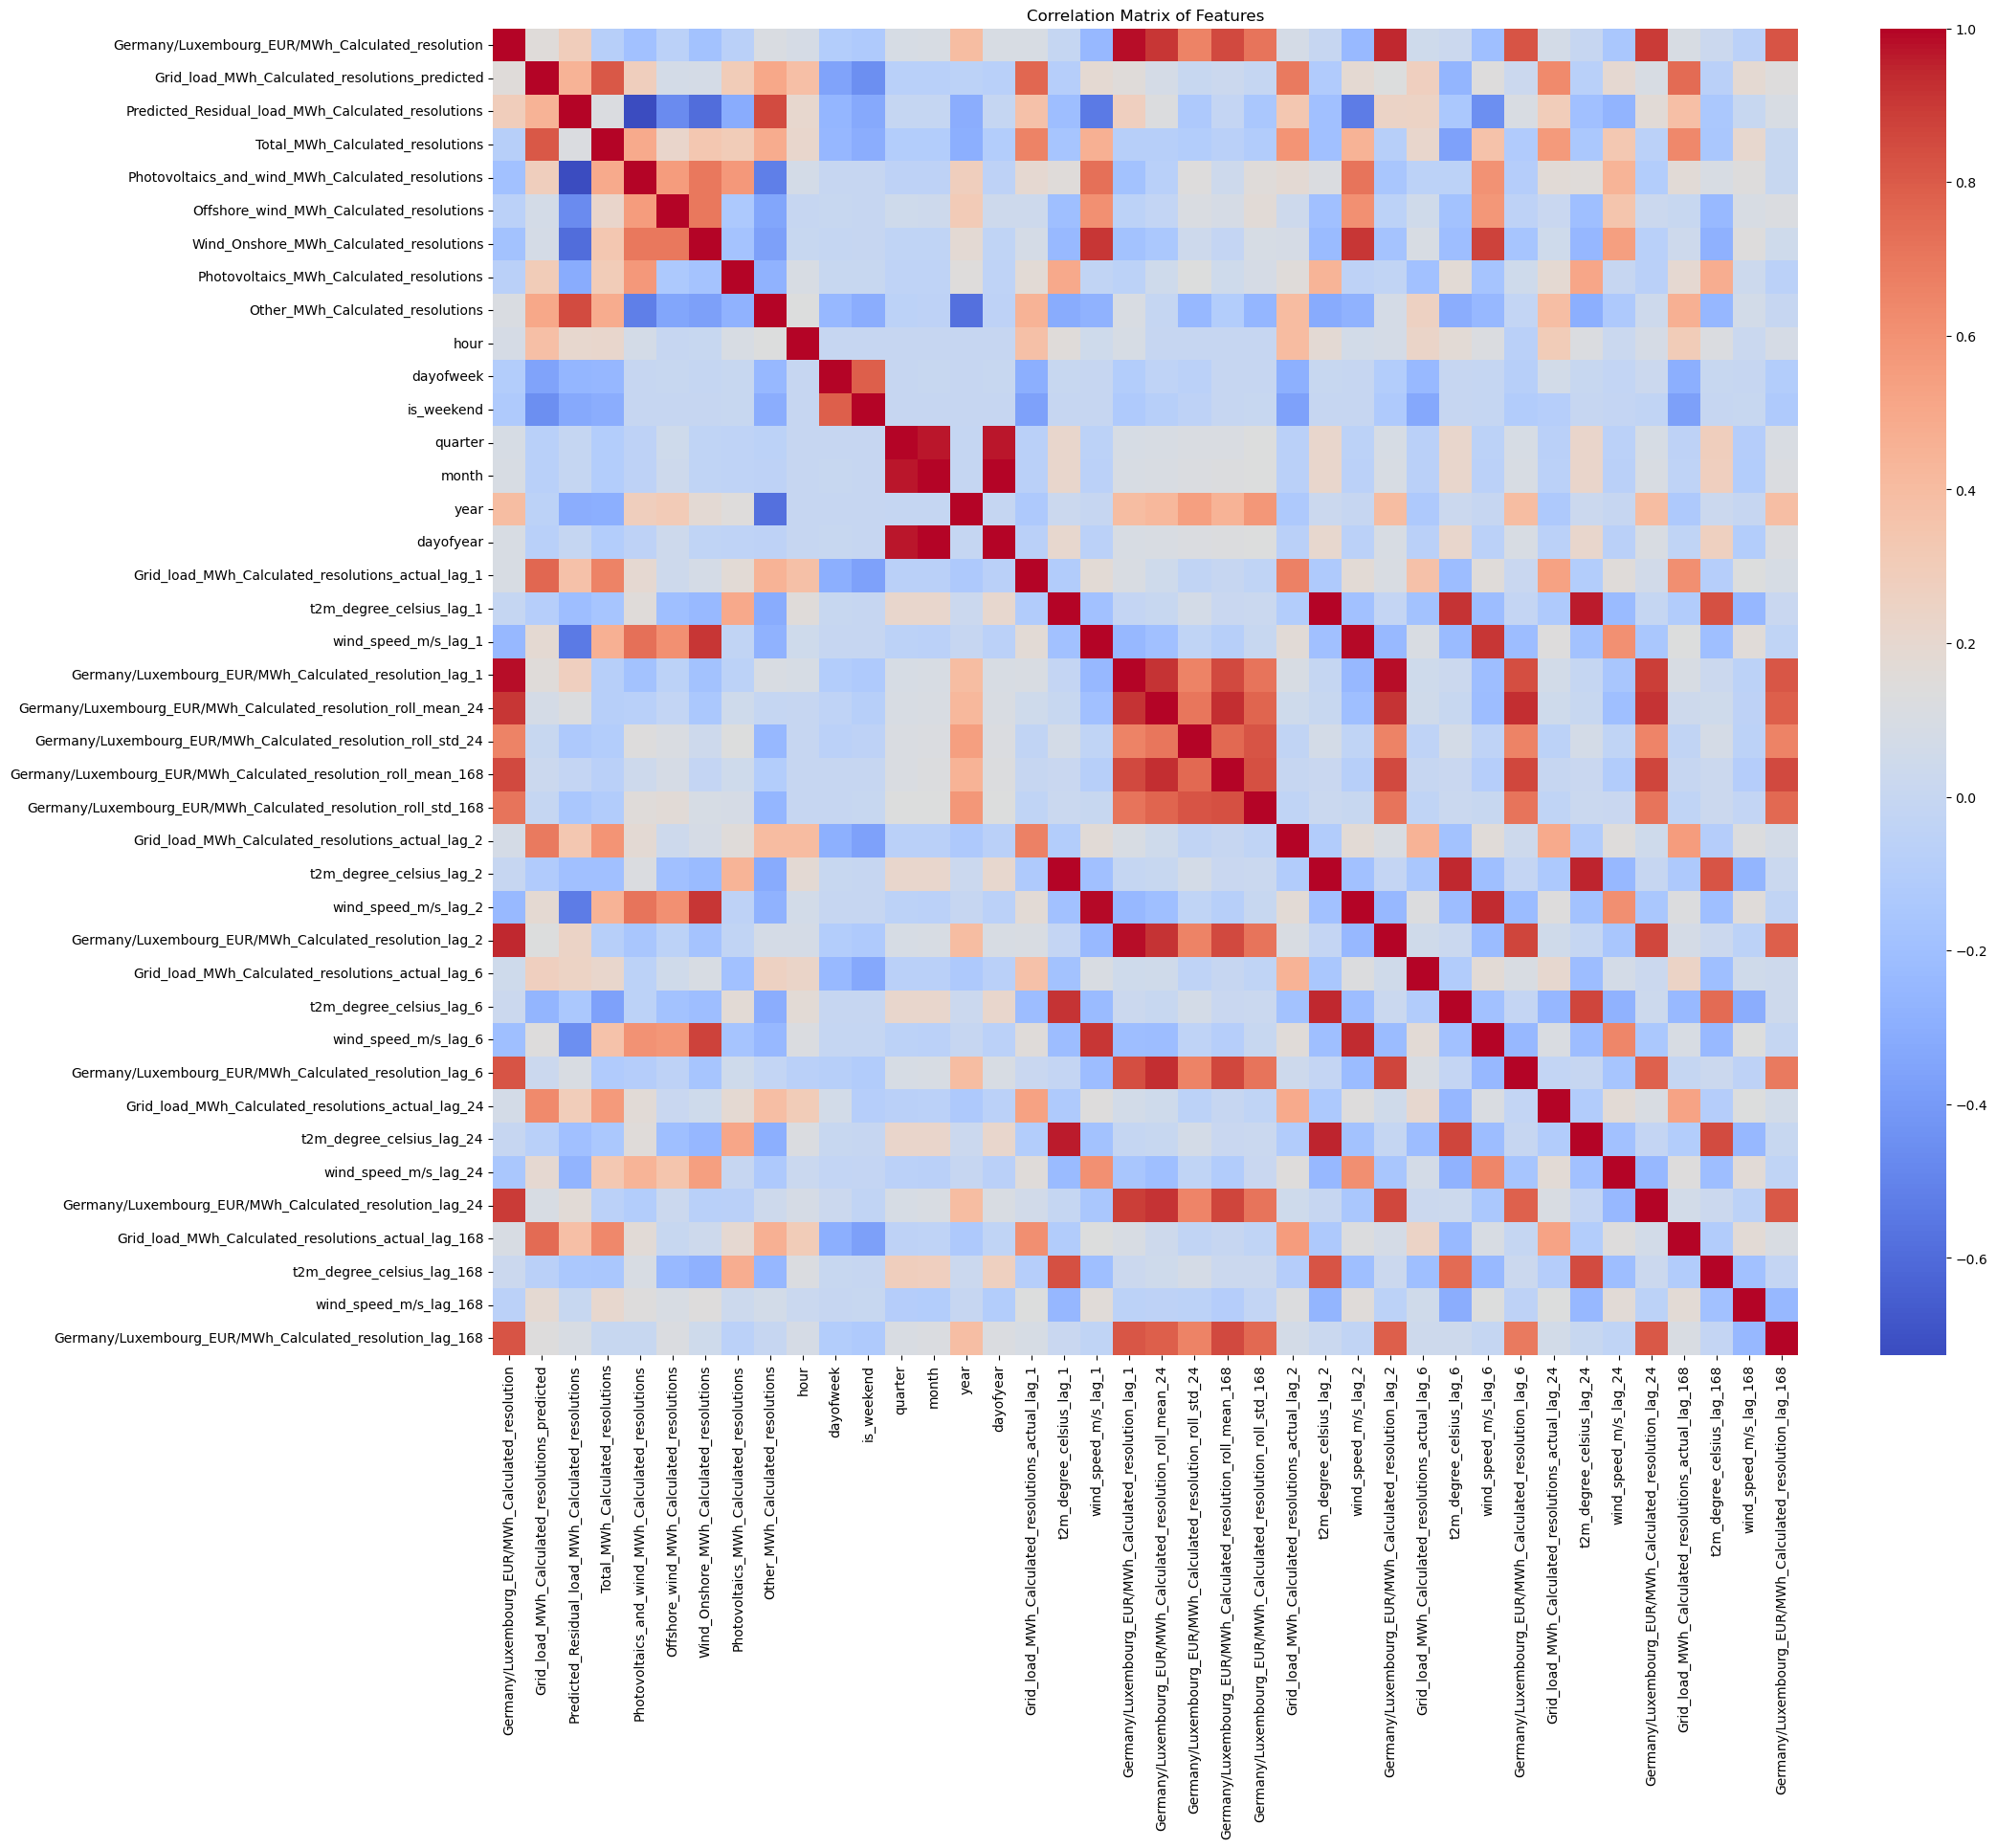

In [41]:
# Check heatmap without annotations
plt.figure(figsize=(22, 18))
sns.heatmap(df_elec_price.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix of Features")
plt.show()

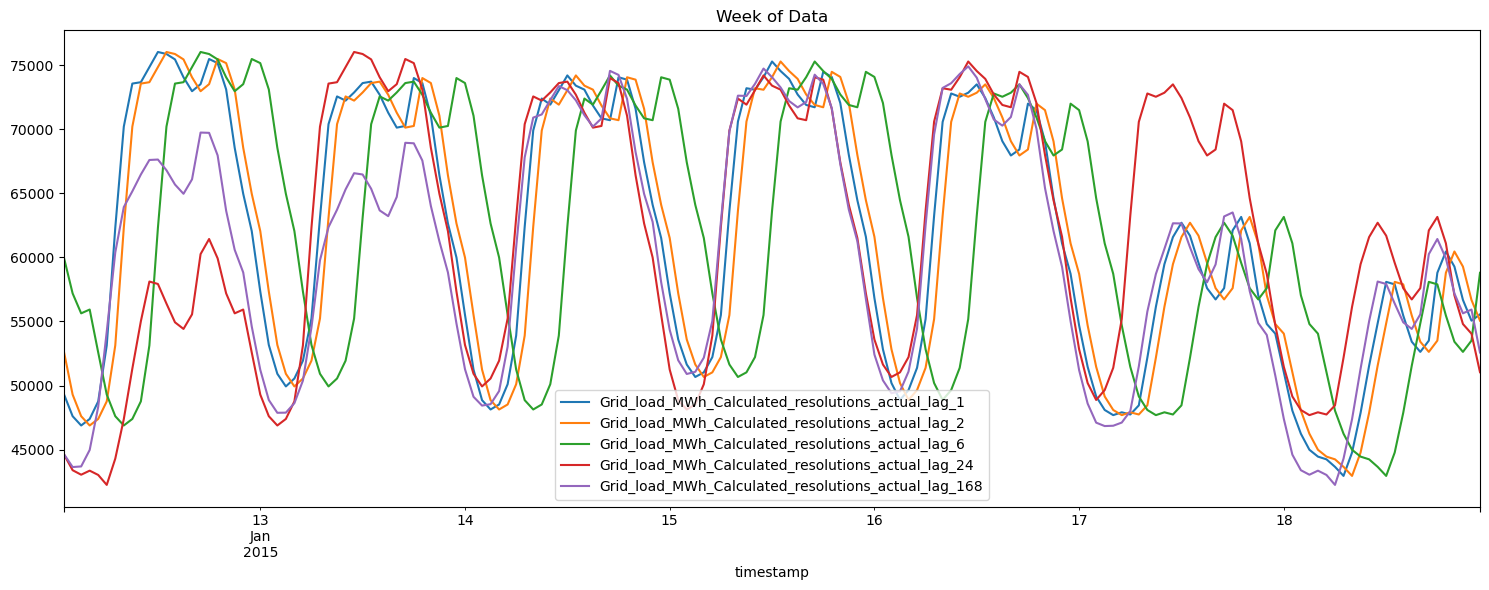

In [42]:
# Plot Grid_load_MWh_Calculated_resolutions_actual Lag Features (in one week) over time
df_elec_price[['Grid_load_MWh_Calculated_resolutions_actual_lag_1',
                'Grid_load_MWh_Calculated_resolutions_actual_lag_2',
               'Grid_load_MWh_Calculated_resolutions_actual_lag_6',
               'Grid_load_MWh_Calculated_resolutions_actual_lag_24',
               'Grid_load_MWh_Calculated_resolutions_actual_lag_168']].loc[(df_elec_price.index > "2015-01-12") & (df_elec_price.index < "2015-01-19")].plot(figsize=(15, 6), title="Week of Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

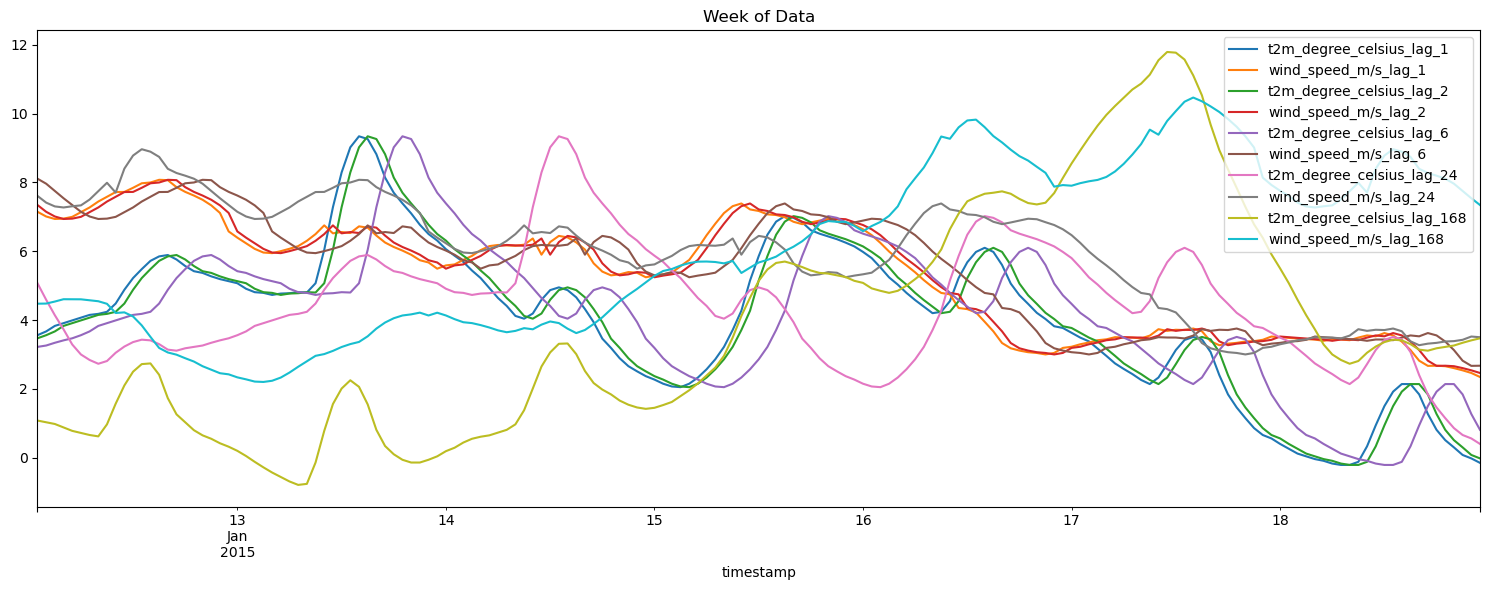

In [43]:
# Plot t2m_degree_celsius lag features, wind_speed_m/s lag features (in one week) over time
df_elec_price[['t2m_degree_celsius_lag_1', 'wind_speed_m/s_lag_1',
               't2m_degree_celsius_lag_2', 'wind_speed_m/s_lag_2',
               't2m_degree_celsius_lag_6', 'wind_speed_m/s_lag_6',
               't2m_degree_celsius_lag_24', 'wind_speed_m/s_lag_24',
               't2m_degree_celsius_lag_168', 'wind_speed_m/s_lag_168']].loc[(df_elec_price.index > "2015-01-12") & (df_elec_price.index < "2015-01-19")].plot(figsize=(15, 6), title="Week of Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

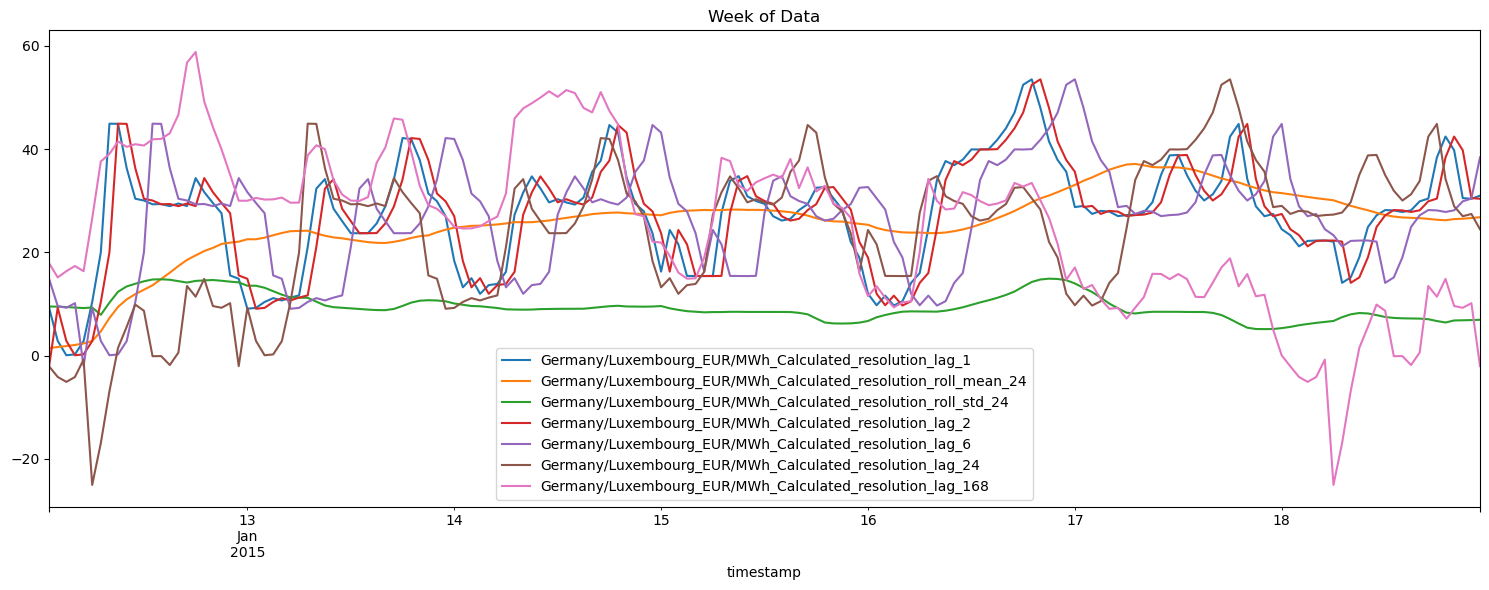

In [44]:
# Plot Germany/Luxembourg_EUR/MWh_Calculated_resolution lag features (in one week) over time
df_elec_price[['Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_1',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_roll_mean_24',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_roll_std_24',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_2',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_6',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_24',
               'Germany/Luxembourg_EUR/MWh_Calculated_resolution_lag_168']].loc[(df_elec_price.index > "2015-01-12") & (df_elec_price.index < "2015-01-19")].plot(figsize=(15, 6), title="Week of Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()